# Fiber Channel Model for BB84

Generated from the public notebook builder for reproducible analysis.

Notebook 03 extends the ideal BB84 simulator to a direct-fiber channel model. We add a single new module &mdash; `src/channel.py` &mdash; that turns fiber attenuation, detector efficiency, dark counts and misalignment into a per-pulse secure-key rate, and we generate the headline figure of the project: BB84 key rate vs. fiber distance.

Three effects limit performance:

1. **Fiber attenuation** &mdash; $\eta(L) = 10^{-\alpha L / 10}$ with $\alpha = 0.2$ dB/km at the 1550 nm telecom-C minimum.
2. **Detector efficiency** &mdash; $\eta_{det} \approx 0.2$ for InGaAs APDs, up to $\sim 0.9$ for SNSPDs.
3. **Dark counts** &mdash; $p_{dark} \sim 10^{-6}$ per detector per gate, summing to $2 p_{dark}$ across BB84's two detectors.

**Key constraint:** unlike classical telecom, QKD cannot use EDFA amplifiers to overcome fiber loss &mdash; the no-cloning theorem (Notebook 02) forbids it. Attenuation is the fundamental distance-limit driver for direct-fiber QKD, and that is exactly why the headline figure below has a hard cutoff.

**Security caveat.** The non-decoy BB84 curve below is the *idealised single-photon source model*. We also implement the simplified asymptotic decoy-state estimate (Lo, Ma & Chen, 2005) so the realistic weak-coherent-pulse case can be compared directly.

## 1. Bootstrap and imports

In [1]:
from pathlib import Path
import sys


def find_project_root(start=None):
    start = Path.cwd().resolve() if start is None else Path(start).resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'src').is_dir() and (candidate / 'notebooks').is_dir():
            return candidate
    raise RuntimeError('Could not find project root')


PROJECT_ROOT = find_project_root()
FIG_DIR = PROJECT_ROOT / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f'Project root: {PROJECT_ROOT}')


Project root: C:\Users\COWLAR\projects\qkd-protocol-simulator


In [2]:
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt
from scipy.optimize import brentq

from src.channel import (
    fiber_transmittance, bb84_signal_prob, total_detection_prob,
    qber_channel, bb84_key_rate, decoy_bb84_key_rate,
)
from src.info_theory import binary_entropy
from src.plotting import semilogy_positive

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 12, 'figure.dpi': 150})

L_dense = np.linspace(0, 300, 1001)


## 2. Fiber transmittance &mdash; the dB convention

$\eta(L) = 10^{-\alpha L / 10}$. The base is **10**, not $e$. At $\alpha = 0.2$ dB/km, every 50 km adds 10 dB of loss &mdash; a factor of 10 drop in transmittance.

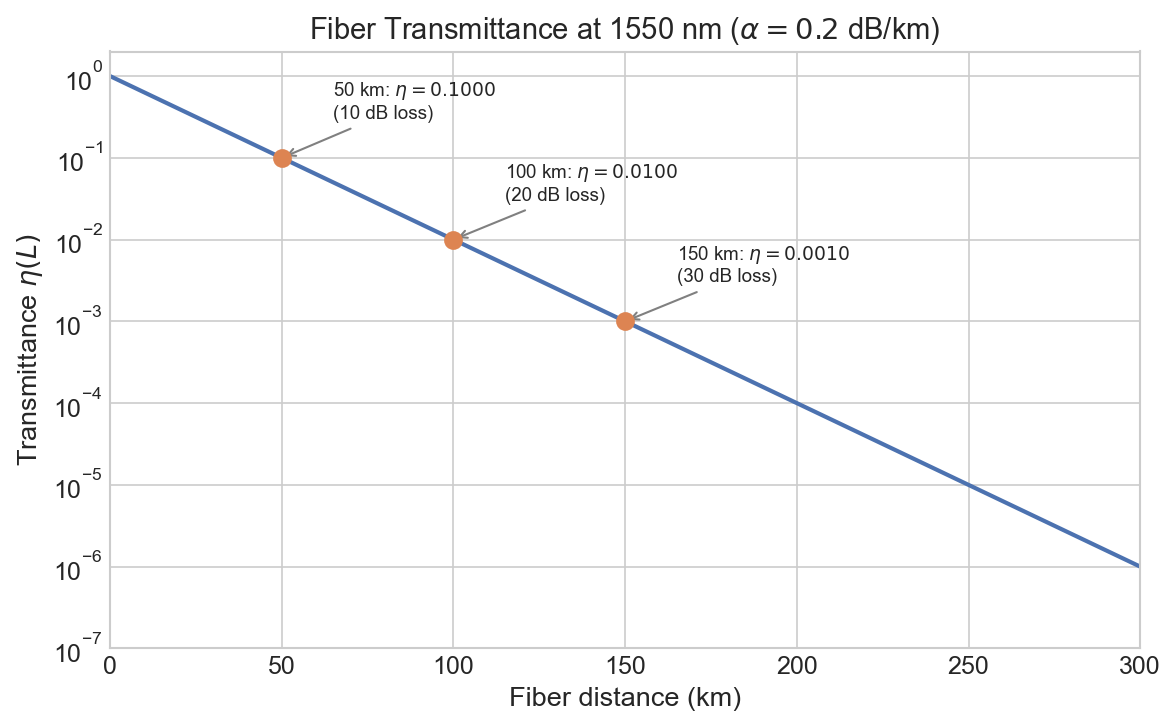

  L =   0 km   ->   eta = 1.000000e+00
  L =  25 km   ->   eta = 3.162278e-01
  L =  50 km   ->   eta = 1.000000e-01
  L =  75 km   ->   eta = 3.162278e-02
  L = 100 km   ->   eta = 1.000000e-02
  L = 150 km   ->   eta = 1.000000e-03
  L = 200 km   ->   eta = 1.000000e-04
  L = 300 km   ->   eta = 1.000000e-06


In [3]:
fig, ax = plt.subplots(figsize=(8, 5))
eta = fiber_transmittance(L_dense)
ax.semilogy(L_dense, eta, '-', color='#4C72B0', linewidth=2)
for Lm, label in [(50, '10 dB'), (100, '20 dB'), (150, '30 dB')]:
    eta_m = fiber_transmittance(Lm)
    ax.plot(Lm, eta_m, 'o', color='#DD8452', markersize=8, zorder=5)
    ax.annotate(
        f'{Lm} km: $\\eta = {eta_m:.4f}$\n({label} loss)',
        xy=(Lm, eta_m), xytext=(Lm + 15, eta_m * 3),
        fontsize=9, arrowprops=dict(arrowstyle='->', color='gray'),
    )
ax.set_xlabel('Fiber distance (km)', fontsize=13)
ax.set_ylabel(r'Transmittance $\eta(L)$', fontsize=13)
ax.set_title(r'Fiber Transmittance at 1550 nm '
             r'($\alpha = 0.2$ dB/km)', fontsize=14)
ax.set_xlim(0, 300)
ax.set_ylim(1e-7, 2)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fiber_transmittance.png', dpi=300,
            bbox_inches='tight')
plt.show()

for Lm in [0, 25, 50, 75, 100, 150, 200, 300]:
    print(f'  L = {Lm:>3} km   ->   eta = {fiber_transmittance(Lm):.6e}')


## 3. QBER from dark counts and misalignment

The two-detector model:

* signal: $S(L) = \eta_{ch}(L)\,\eta_{det}\,\mu$
* gain: $Q(L) = S(L) + 2\,p_{dark}$
* QBER: $E(L) = (e_{det}\,S + p_{dark}) / Q$

Why the asymmetry? Both detectors fire dark counts (so $Q$ uses $2 p_{dark}$), but only one detector fires *erroneously* per dark event &mdash; if a single dark click happens, it lands in the wrong detector with probability 1/2, so the QBER numerator uses $p_{dark}$, not $2 p_{dark}$ .

Limits:

* short distance (with $e_{det} = 0$): $E \approx p_{dark} / S \to 0$ &mdash; the textbook "$E \approx p_{dark}$" is dimensionally wrong; the right approximation is $p_{dark}/(\eta_{ch}\,\eta_{det}\,\mu)$.
* long distance: $S \to 0$, $E \to p_{dark}/(2 p_{dark}) = 0.5$ (every click is a coin flip).

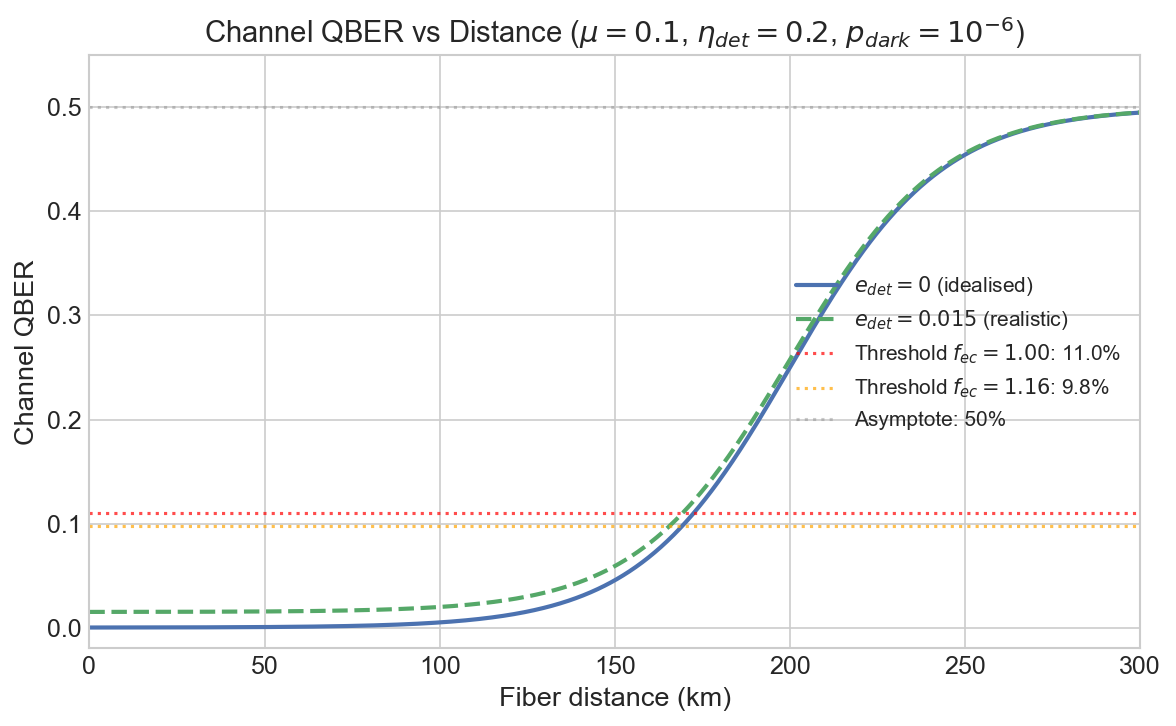

In [4]:
fig, ax = plt.subplots(figsize=(8, 5))
qber = qber_channel(L_dense)
qber_with_misalign = qber_channel(L_dense, e_det=0.015)
ax.plot(L_dense, qber, '-', color='#4C72B0', linewidth=2,
        label=r'$e_{det}=0$ (idealised)')
ax.plot(L_dense, qber_with_misalign, '--', color='#55A868', linewidth=2,
        label=r'$e_{det}=0.015$ (realistic)')
ax.axhline(0.110, color='red', linestyle=':', alpha=0.7,
           label=r'Threshold $f_{ec}=1.00$: 11.0%')
ax.axhline(0.098, color='orange', linestyle=':', alpha=0.7,
           label=r'Threshold $f_{ec}=1.16$: 9.8%')
ax.axhline(0.5, color='gray', linestyle=':', alpha=0.4,
           label='Asymptote: 50%')
ax.set_xlabel('Fiber distance (km)', fontsize=13)
ax.set_ylabel('Channel QBER', fontsize=13)
ax.set_title(r'Channel QBER vs Distance '
             r'($\mu=0.1$, $\eta_{det}=0.2$, $p_{dark}=10^{-6}$)',
             fontsize=14)
ax.legend(fontsize=10, loc='center right')
ax.set_xlim(0, 300)
ax.set_ylim(-0.02, 0.55)
plt.tight_layout()
plt.savefig(FIG_DIR / 'qber_vs_distance.png', dpi=300,
            bbox_inches='tight')
plt.show()


## 4. The headline figure &mdash; BB84 key rate vs. distance

$$K(L) = \tfrac{1}{2}\,Q(L)\,\max\bigl(0,\;1 - h(E) - f_{ec}\,h(E)\bigr)$$

with sifting factor $q = 1/2$. Notebook 01 reported a per-sifted-bit rate; Notebook 03 multiplies by $q$ and the gain $Q$ to land on a per-emitted-pulse rate.

The figure uses a semilogy axis. **Log-scale rule:** we plot only positive rates via `semilogy_positive(...)` and mark the cutoff with a vertical dashed line. Drawing $K = 0$ on a log axis is meaningless and would dominate the plot.

**Idealised single-photon source model.** The realistic decoy-state weak-coherent estimate is plotted in the next section.